In [1]:
import sccellfie
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import glasbey

import textwrap

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import anndata as ad

In [3]:
sc.settings.figdir = '/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/da-figures/'

In [ ]:
Honda_scCellFie_healthy_ctrl.

In [5]:
adata = sccellfie.io.load_adata(folder='/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie',
                                filename='Honda_scCellFie_healthy_ctrl'
                               )

/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_healthy_ctrl.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_healthy_ctrl_reactions.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_healthy_ctrl_metabolic_tasks.h5ad was correctly loaded


In [6]:
adata

AnnData object with n_obs × n_vars = 6198 × 682
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr'
    uns: 'cell_annotation_05_colors', 'condition_color

In [7]:
adata.metabolic_tasks

AnnData object with n_obs × n_vars = 6198 × 181
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_2', 'rna_leiden_colors', 'sample_id_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## Defining cell types

In [8]:
cell_group = 'cell_annotation_05'

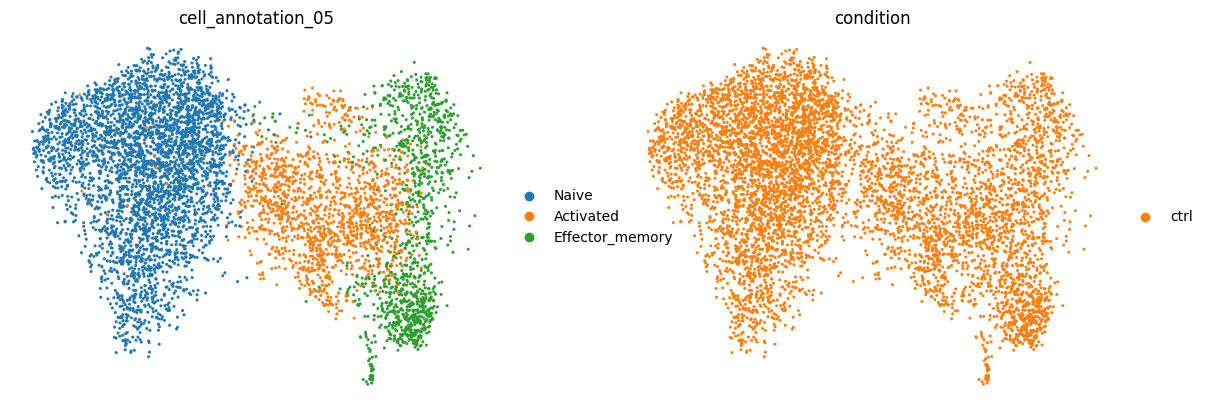

In [9]:
sc.pl.umap(adata, color=[cell_group,"condition"],frameon=False)

In [10]:
adata.metabolic_tasks.obs

,sample_id,batch,initial_size_unspliced,initial_size_spliced,initial_size,sample_batch,condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,log1p_total_counts_hb,pct_counts_hb,n_genes,rna_leiden,doublet_score,predicted_doublet,rna_leiden_12,rna_leiden_2,cell_annotation_05,n_counts
AAAGCAAGTGAG,2019_10mix1,2019_10mix1,260.0,134.0,134.0,10mix1_GCTA-1,ctrl,1440,7.273093,222.328384,...,0.0,0.0,1440,1,0.059578,False,2,2,Naive,222.328384
AACTCAGTCGCG,2019_10mix1,2019_10mix1,200.0,101.0,101.0,10mix1_TTTC-1,ctrl,1430,7.266129,223.999985,...,0.0,0.0,1430,1,0.062619,False,0,4,Naive,223.999985
AAAGTAGGTTCC,2019_10mix1,2019_10mix1,286.0,164.0,164.0,10mix1_GTCT-1,ctrl,1390,7.237778,224.000015,...,0.0,0.0,1390,2,0.216495,False,2,16,Naive,224.000015
AAATGCCAGTAG,2019_10mix1,2019_10mix1,522.0,347.0,347.0,10mix1_CCGA-1,ctrl,2364,7.768533,222.708954,...,0.0,0.0,2361,4,0.041096,False,10,15,Activated,222.708954
AACTCAGCATTT,2019_10mix1,2019_10mix1,626.0,514.0,514.0,10mix1_CACT-1,ctrl,2142,7.669962,223.999985,...,0.0,0.0,2138,2,0.149254,False,2,1,Naive,223.999985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCTCGTG,2019_10mix2,2019_10mix2,327.0,210.0,210.0,10mix2_GGAA-1,ctrl,1913,7.556951,224.000000,...,0.0,0.0,1911,5,0.088858,False,5,7,Activated,224.000000
TTTGGTTTCTGG,2019_10mix2,2019_10mix2,395.0,215.0,215.0,10mix2_CGAC-1,ctrl,1814,7.503841,224.000000,...,0.0,0.0,1812,1,0.110368,False,0,10,Naive,224.000000
TTTCCTCAGCAC,2019_10mix2,2019_10mix2,527.0,836.0,836.0,10mix2_CGTC-1,ctrl,2368,7.770223,223.732071,...,0.0,0.0,2365,5,0.083110,False,5,7,Activated,223.732071
TTTGTCACAATC,2019_10mix2,2019_10mix2,590.0,513.0,513.0,10mix2_TGCA-1,ctrl,2101,7.650645,224.000000,...,0.0,0.0,2099,2,0.141684,False,2,1,Naive,224.000000


## Identification of metabolic markers

## Detection using TF-IDF

In [11]:
mrks = sccellfie.external.quick_markers(adata.metabolic_tasks,
                                        cluster_key=cell_group,
                                        n_markers=20,
                                        express_cut=5*np.log(2))

<Axes: >

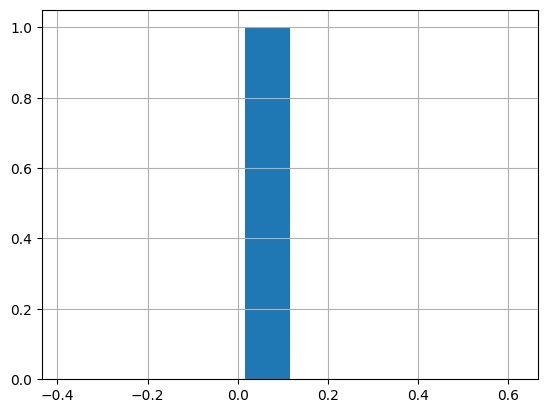

In [12]:
# Visualize TF-IDF score distribution
mrks['tf_idf'].hist()

Text(0, 0.5, 'IDF')

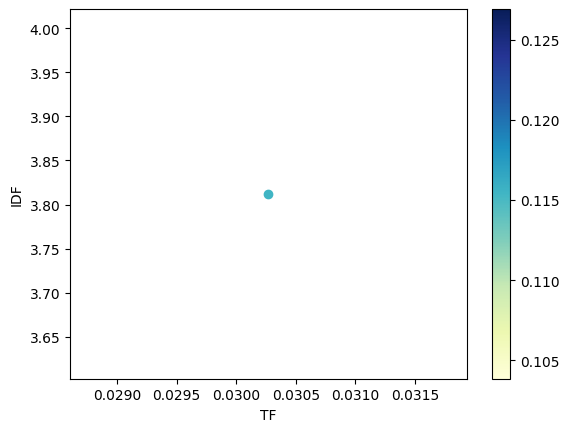

In [13]:
# Scatter plot of TF vs IDF with TF-IDF as color
scatter = plt.scatter(mrks['tf'], mrks['idf'], c=mrks['tf_idf'], cmap='YlGnBu')
plt.colorbar(scatter)
plt.xlabel('TF')
plt.ylabel('IDF')

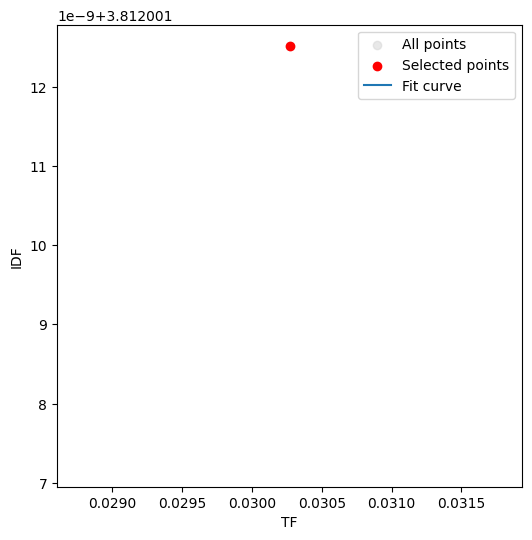

In [14]:
x_col = 'tf'
y_col = 'idf'
df = mrks
tfidf_threshold = 0.1
tf_ratio = 1.2

# Visualization
plt.figure(figsize=(6, 6))
# Plot all points
plt.scatter(df[x_col], df[y_col], alpha=0.5, c='lightgray', label='All points')
# Plot selected points
filtered_mrks, curve = sccellfie.external.filter_tfidf_markers(df, tf_col=x_col, idf_col=y_col,
                                                              tfidf_threshold=tfidf_threshold,
                                                              tf_ratio=tf_ratio)
plt.scatter(filtered_mrks[x_col], filtered_mrks[y_col], c='red', label='Selected points')
plt.plot(*curve, label='Fit curve')
plt.xlabel('TF')
plt.ylabel('IDF')
plt.legend()

In [15]:
# Get unique list of filtered markers
tf_idf_mrks = filtered_mrks['gene'].unique().tolist()
len(tf_idf_mrks)

1

## Logistic regression

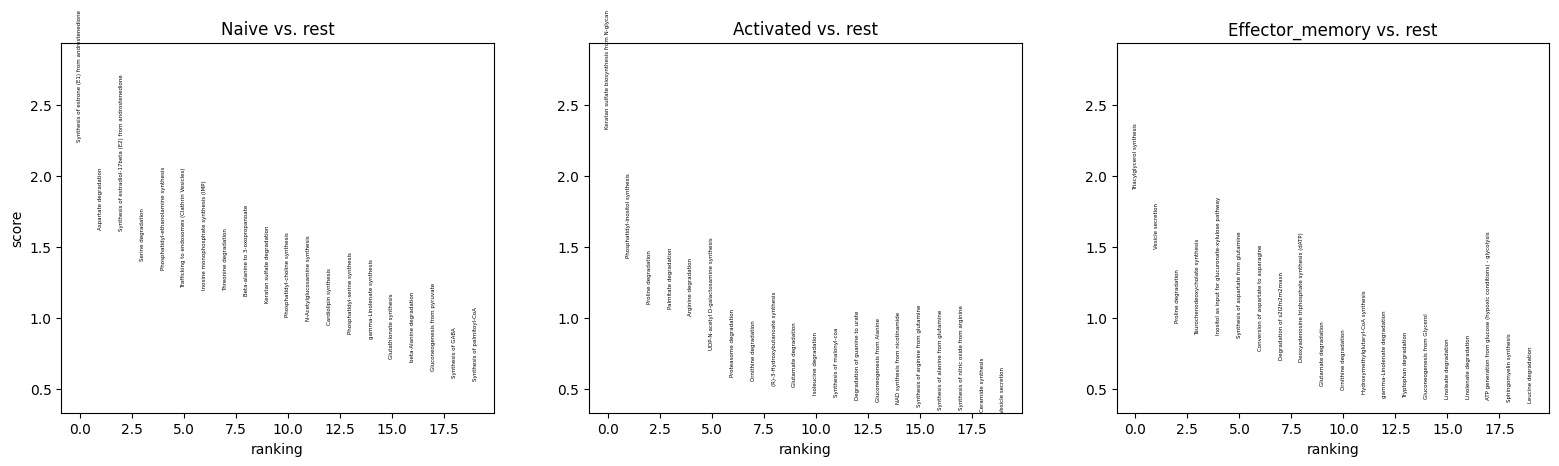

In [16]:
method = 'logreg'
sc.tl.rank_genes_groups(adata.metabolic_tasks, cell_group, method=method,
                       use_raw=False, key_added=method)
sc.pl.rank_genes_groups(adata.metabolic_tasks, n_genes=20, sharey=True, key=method, fontsize=4)

In [17]:
# Get the results as a dataframe
scanpy_df = sc.get.rank_genes_groups_df(adata.metabolic_tasks,
                                      key=method,
                                      group=None)

In [18]:
scanpy_df

,group,names,scores
0,Naive,Synthesis of estrone (E1) from androstenedione,2.242753
1,Naive,Aspartate degradation,1.623738
2,Naive,Synthesis of estradiol-17beta (E2) from andros...,1.617413
3,Naive,Serine degradation,1.408728
4,Naive,Phosphatidyl-ethanolamine synthesis,1.344884
...,...,...,...
538,Effector_memory,Trafficking to endosomes (Clathrin Vesicles),-0.908672
539,Effector_memory,Synthesis of alanine from glutamine,-0.915429
540,Effector_memory,(R)-3-Hydroxybutanoate synthesis,-0.955456
541,Effector_memory,Synthesis of estrone (E1) from androstenedione,-1.054980


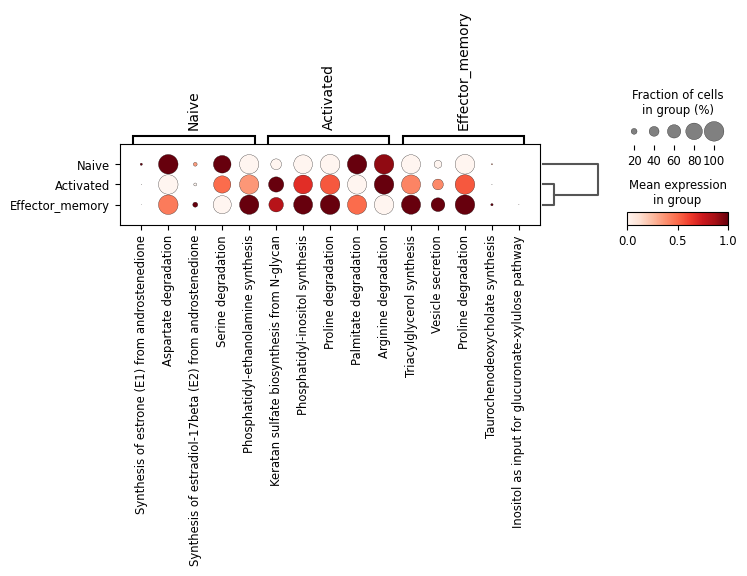

In [19]:
sc.pl.rank_genes_groups_dotplot(adata.metabolic_tasks, n_genes=5, groupby=cell_group,
                               key=method, use_raw=False, standard_scale='var',
                              )

<Axes: >

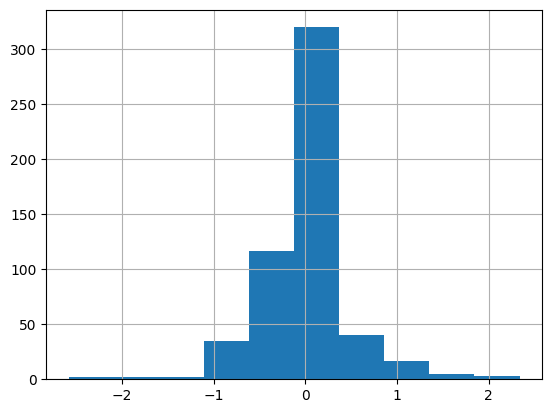

In [20]:
scanpy_df['scores'].hist()

In [21]:
# Filter based on score threshold
scores_threshold = 0.5
filtered_scanpy_mrks = scanpy_df.loc[scanpy_df['scores'] > scores_threshold]

In [22]:
filtered_scanpy_mrks

,group,names,scores
0,Naive,Synthesis of estrone (E1) from androstenedione,2.242753
1,Naive,Aspartate degradation,1.623738
2,Naive,Synthesis of estradiol-17beta (E2) from andros...,1.617413
3,Naive,Serine degradation,1.408728
4,Naive,Phosphatidyl-ethanolamine synthesis,1.344884
5,Naive,Trafficking to endosomes (Clathrin Vesicles),1.213798
6,Naive,Inosine monophosphate synthesis (IMP),1.203922
7,Naive,Threonine degradation,1.197666
8,Naive,Beta-alanine to 3-oxopropanoate,1.160171
9,Naive,Keratan sulfate degradation,1.111014


In [23]:
# Convert them to a list
scanpy_mrks = filtered_scanpy_mrks['names'].unique().tolist()
len(scanpy_mrks)

39

## Visualization

In [24]:
both_markers = sorted(set(tf_idf_mrks + scanpy_mrks))
len(both_markers)

40

In [25]:
# Aggregate the metabolic activity of markers into a cell-type level using trimean
agg = sccellfie.expression.aggregation.agg_expression_cells(adata.metabolic_tasks[:, both_markers],
                                                            groupby=cell_group,
                                                            agg_func='trimean')

In [26]:
agg

Task,(R)-3-Hydroxybutanoate synthesis,Arginine degradation,Aspartate degradation,Beta-alanine to 3-oxopropanoate,Cardiolipin synthesis,Conversion of aspartate to asparagine,Conversion of histidine to histamine,Degradation of s2l2fn2m2masn,Deoxyadenosine triphosphate synthesis (dATP),Gluconeogenesis from pyruvate,...,Synthesis of estrone (E1) from androstenedione,Synthesis of palmitoyl-CoA,Taurochenodeoxycholate synthesis,Threonine degradation,Trafficking to endosomes (Clathrin Vesicles),Triacylglycerol synthesis,UDP-N-acetyl D-galactosamine synthesis,Vesicle secretion,beta-Alanine degradation,gamma-Linolenate synthesis
Activated,0.413923,0.356566,0.354913,0.0,0.255979,0.0,0.0,0.003765,0.129384,0.280153,...,0.0,0.376048,0.0,0.361905,0.025234,0.248397,0.109919,0.047150,0.354839,0.0
Effector_memory,0.429322,0.349767,0.364289,0.0,0.257045,0.0,0.0,0.009081,0.165499,0.302811,...,0.0,0.369809,0.0,0.392666,0.040242,0.262888,0.109611,0.139931,0.361989,0.0
Naive,0.355041,0.356054,0.374292,0.0,0.249819,0.0,0.0,0.004584,0.169605,0.254632,...,0.0,0.354330,0.0,0.387617,0.000000,0.240147,0.087481,0.021335,0.366888,0.0


In [32]:
both_markers = agg.T.loc[(agg.T > 0.1).any(axis=1)].index.tolist()
len(both_markers)

24

In [33]:
both_markers

['(R)-3-Hydroxybutanoate synthesis',
 'Arginine degradation',
 'Aspartate degradation',
 'Cardiolipin synthesis',
 'Deoxyadenosine triphosphate synthesis (dATP)',
 'Gluconeogenesis from pyruvate',
 'Glutamate degradation',
 'Inosine monophosphate synthesis (IMP)',
 'N-Acetylglucosamine synthesis',
 'Ornithine degradation',
 'Palmitate degradation',
 'Phosphatidyl-choline synthesis',
 'Phosphatidyl-ethanolamine synthesis',
 'Phosphatidyl-inositol synthesis',
 'Phosphatidyl-serine synthesis',
 'Proline degradation',
 'Serine degradation',
 'Synthesis of aspartate from glutamine',
 'Synthesis of palmitoyl-CoA',
 'Threonine degradation',
 'Triacylglycerol synthesis',
 'UDP-N-acetyl D-galactosamine synthesis',
 'Vesicle secretion',
 'beta-Alanine degradation']

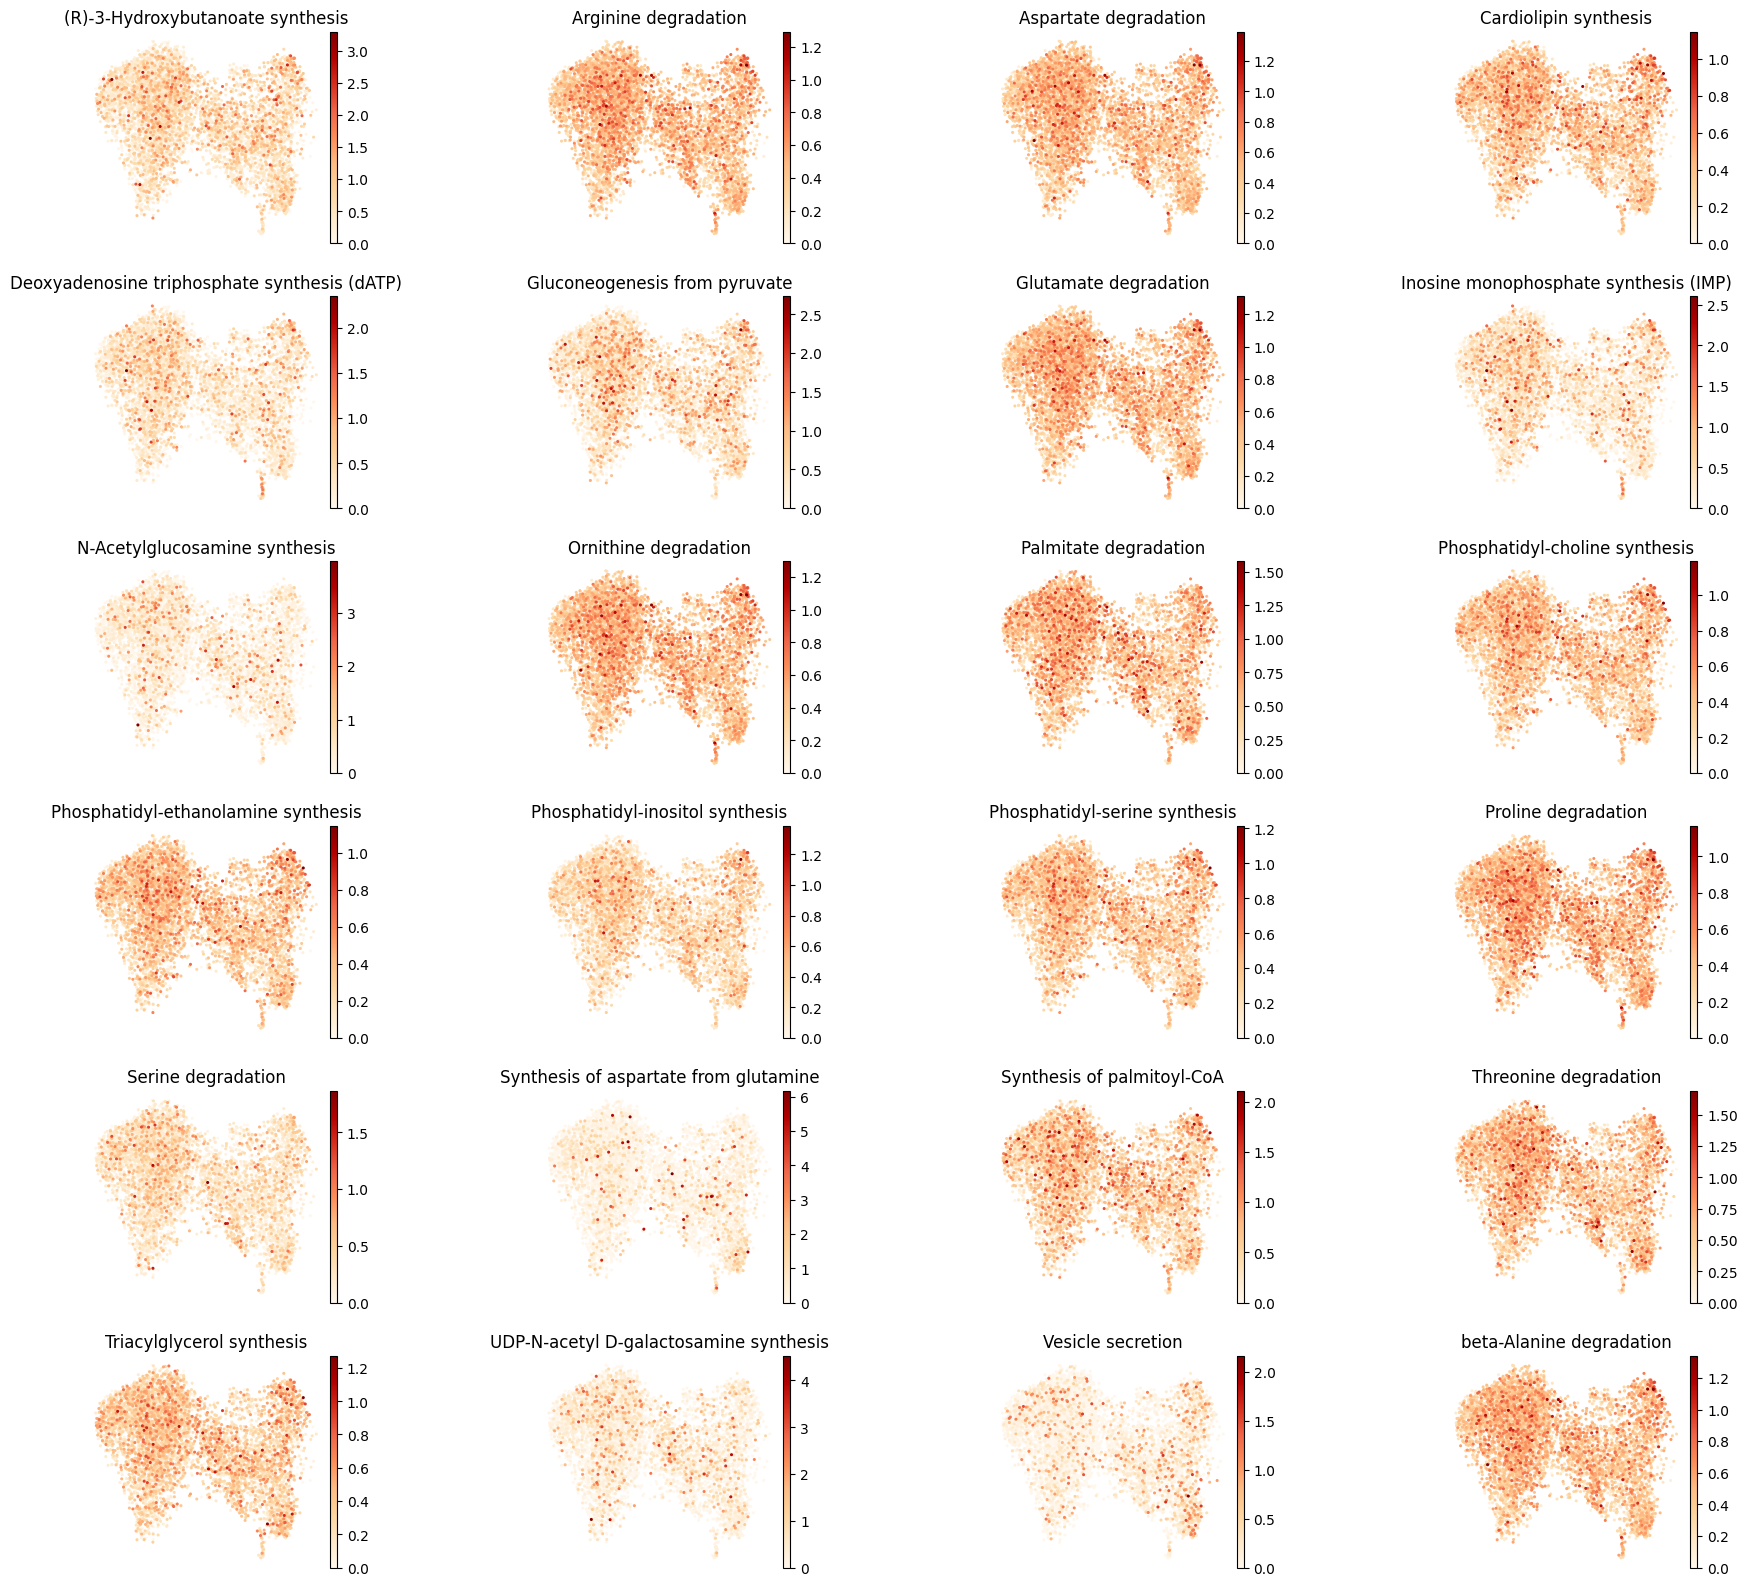

In [34]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['font.size'] = 10

sc.pl.embedding(adata.metabolic_tasks,
               color=both_markers,
               ncols=4,
               #palette=palette,
               frameon=False,
               basis='X_umap',
               wspace=0.7,
               title=["\n".join(textwrap.wrap(t, width=45)) for t in both_markers],
               cmap='OrRd'
              )

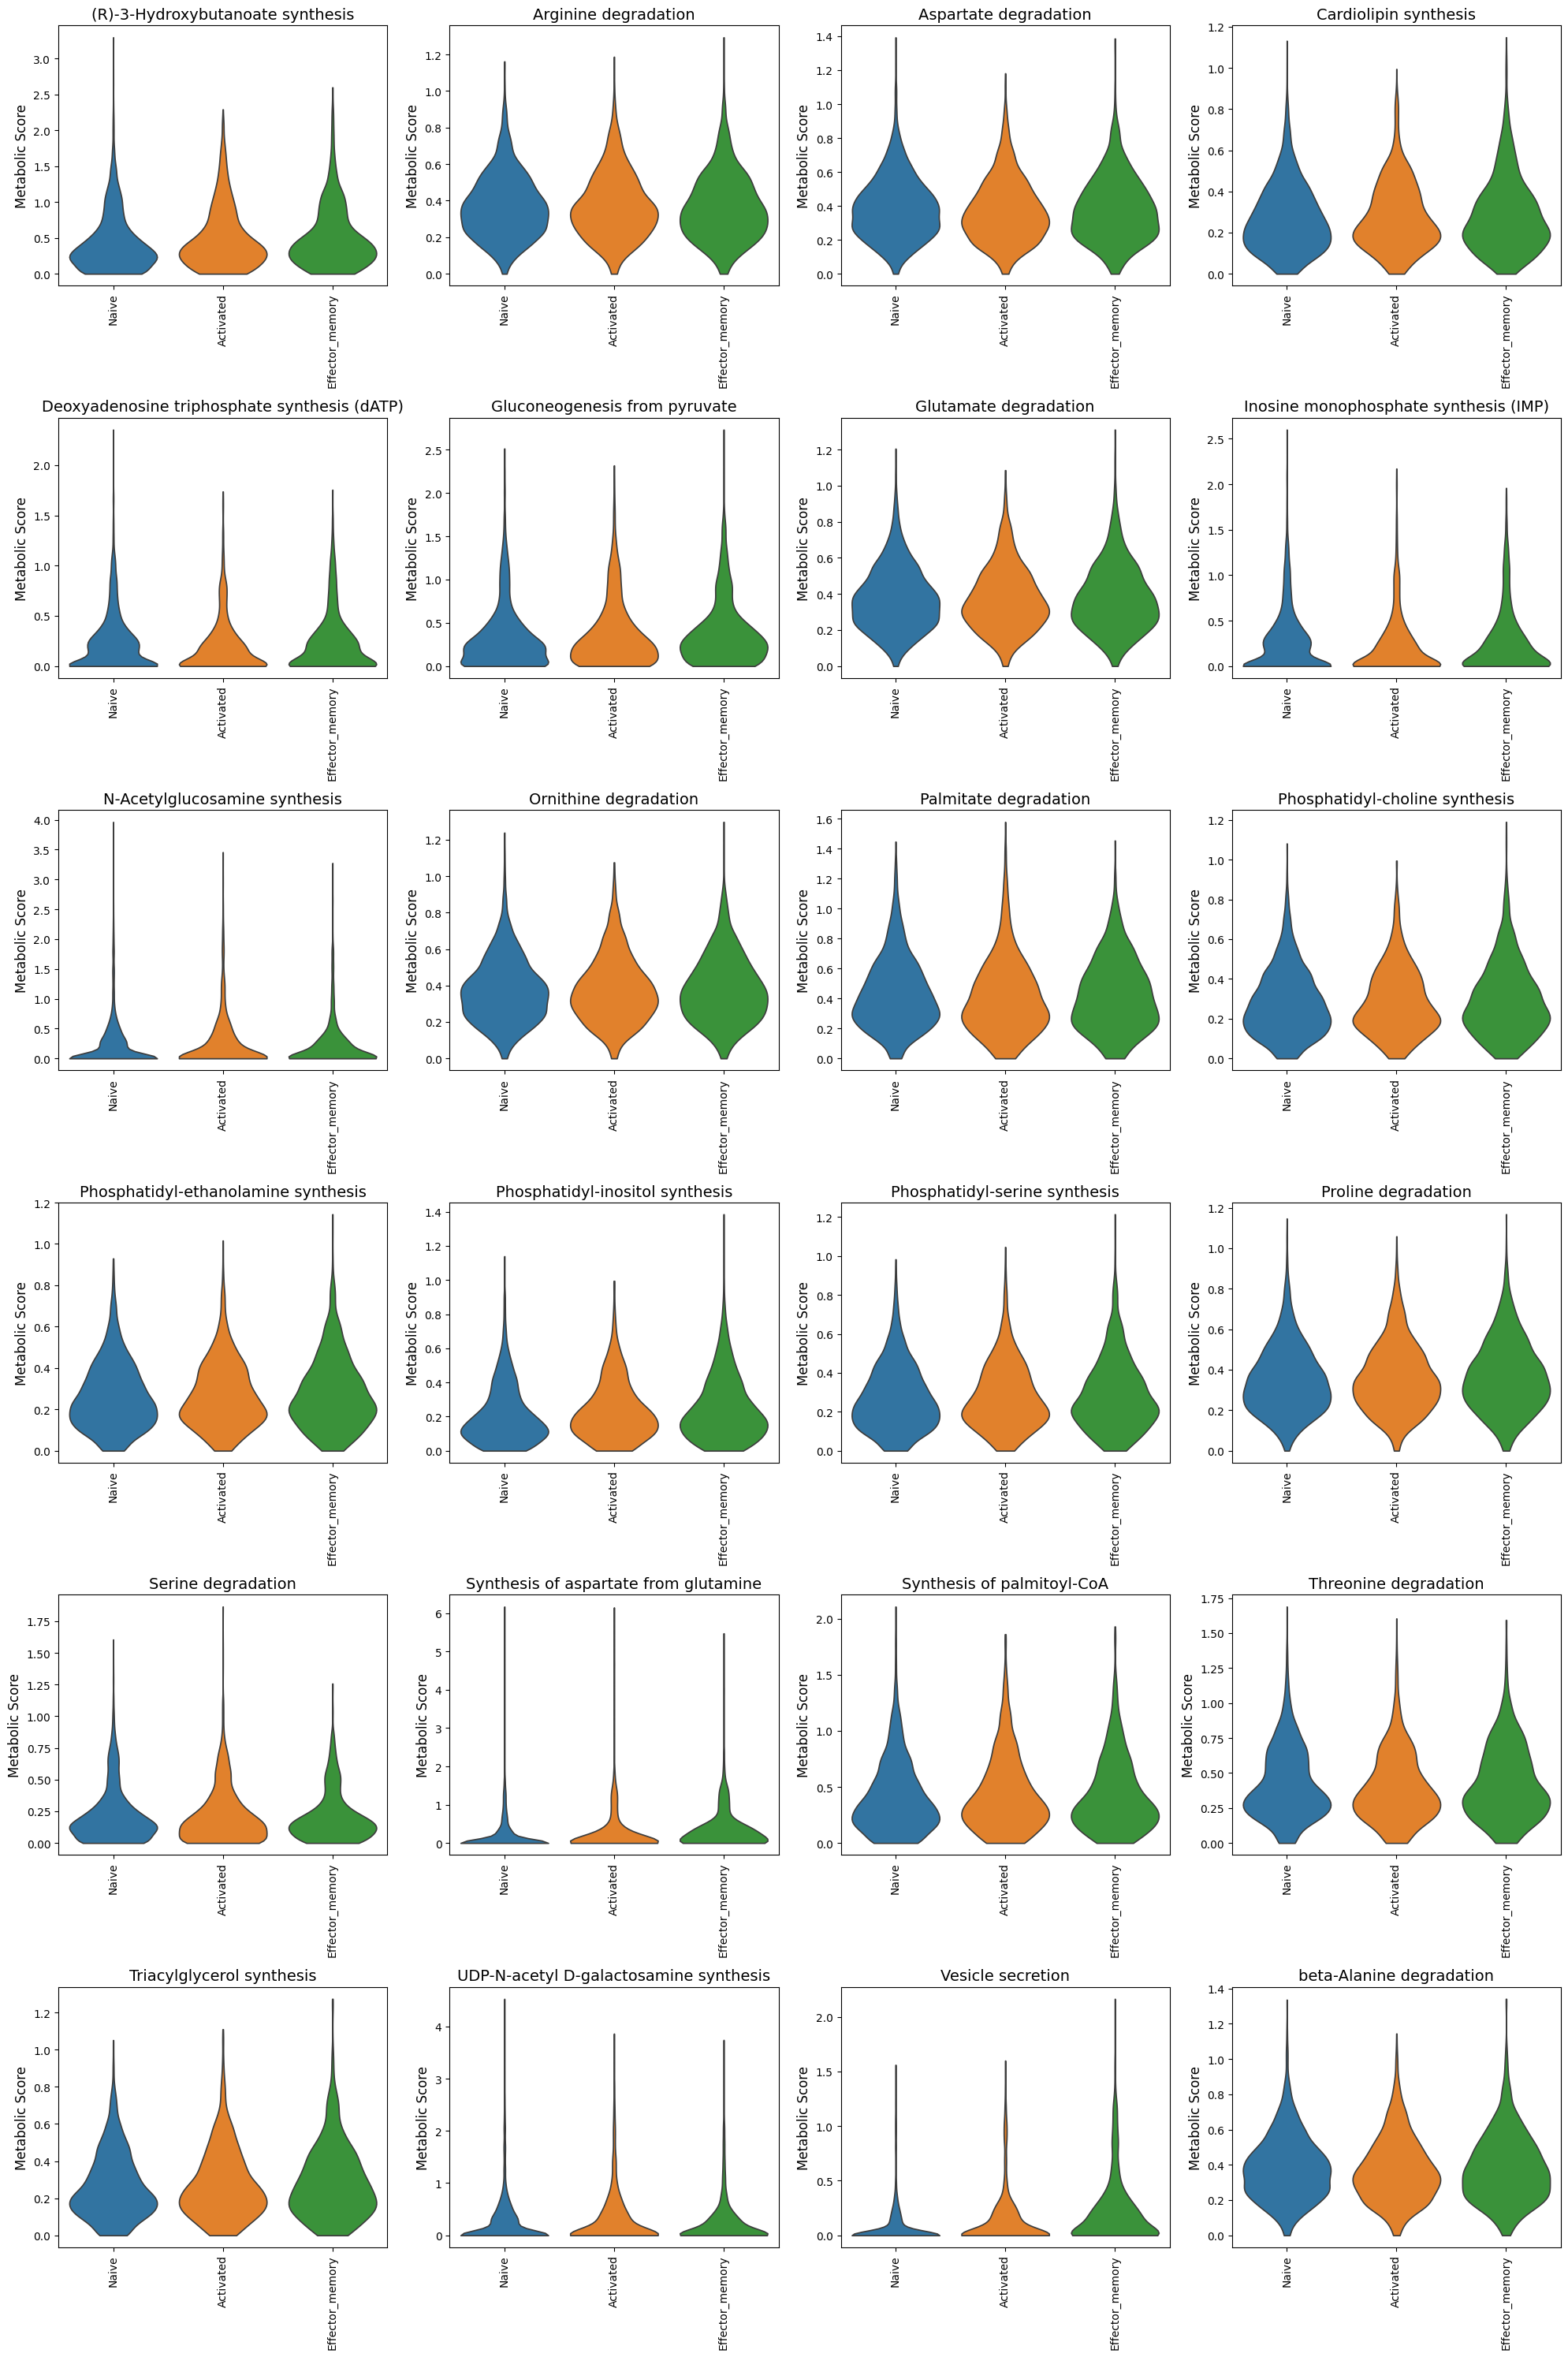

In [35]:
fig, axes = sccellfie.plotting.create_multi_violin_plots(adata.metabolic_tasks,
                                                       features=both_markers,
                                                       groupby=cell_group,
                                                       stripplot=False,
                                                       n_cols=4,
                                                       ylabel='Metabolic Score'
                                                      )

In [36]:
filtered_agg = agg[both_markers]

In [37]:
filtered_agg.head()

Task,(R)-3-Hydroxybutanoate synthesis,Arginine degradation,Aspartate degradation,Cardiolipin synthesis,Deoxyadenosine triphosphate synthesis (dATP),Gluconeogenesis from pyruvate,Glutamate degradation,Inosine monophosphate synthesis (IMP),N-Acetylglucosamine synthesis,Ornithine degradation,...,Phosphatidyl-serine synthesis,Proline degradation,Serine degradation,Synthesis of aspartate from glutamine,Synthesis of palmitoyl-CoA,Threonine degradation,Triacylglycerol synthesis,UDP-N-acetyl D-galactosamine synthesis,Vesicle secretion,beta-Alanine degradation
Activated,0.413923,0.356566,0.354913,0.255979,0.129384,0.280153,0.356705,0.143500,0.088658,0.357280,...,0.260327,0.344227,0.169796,0.069787,0.376048,0.361905,0.248397,0.109919,0.047150,0.354839
Effector_memory,0.429322,0.349767,0.364289,0.257045,0.165499,0.302811,0.359692,0.163301,0.103528,0.364608,...,0.260303,0.352970,0.163294,0.227669,0.369809,0.392666,0.262888,0.109611,0.139931,0.361989
Naive,0.355041,0.356054,0.374292,0.249819,0.169605,0.254632,0.359625,0.201147,0.077088,0.357576,...,0.253407,0.331568,0.170482,0.057752,0.354330,0.387617,0.240147,0.087481,0.021335,0.366888


In [38]:
normalized_markers = sccellfie.preprocessing.min_max_normalization(filtered_agg, axis=0)

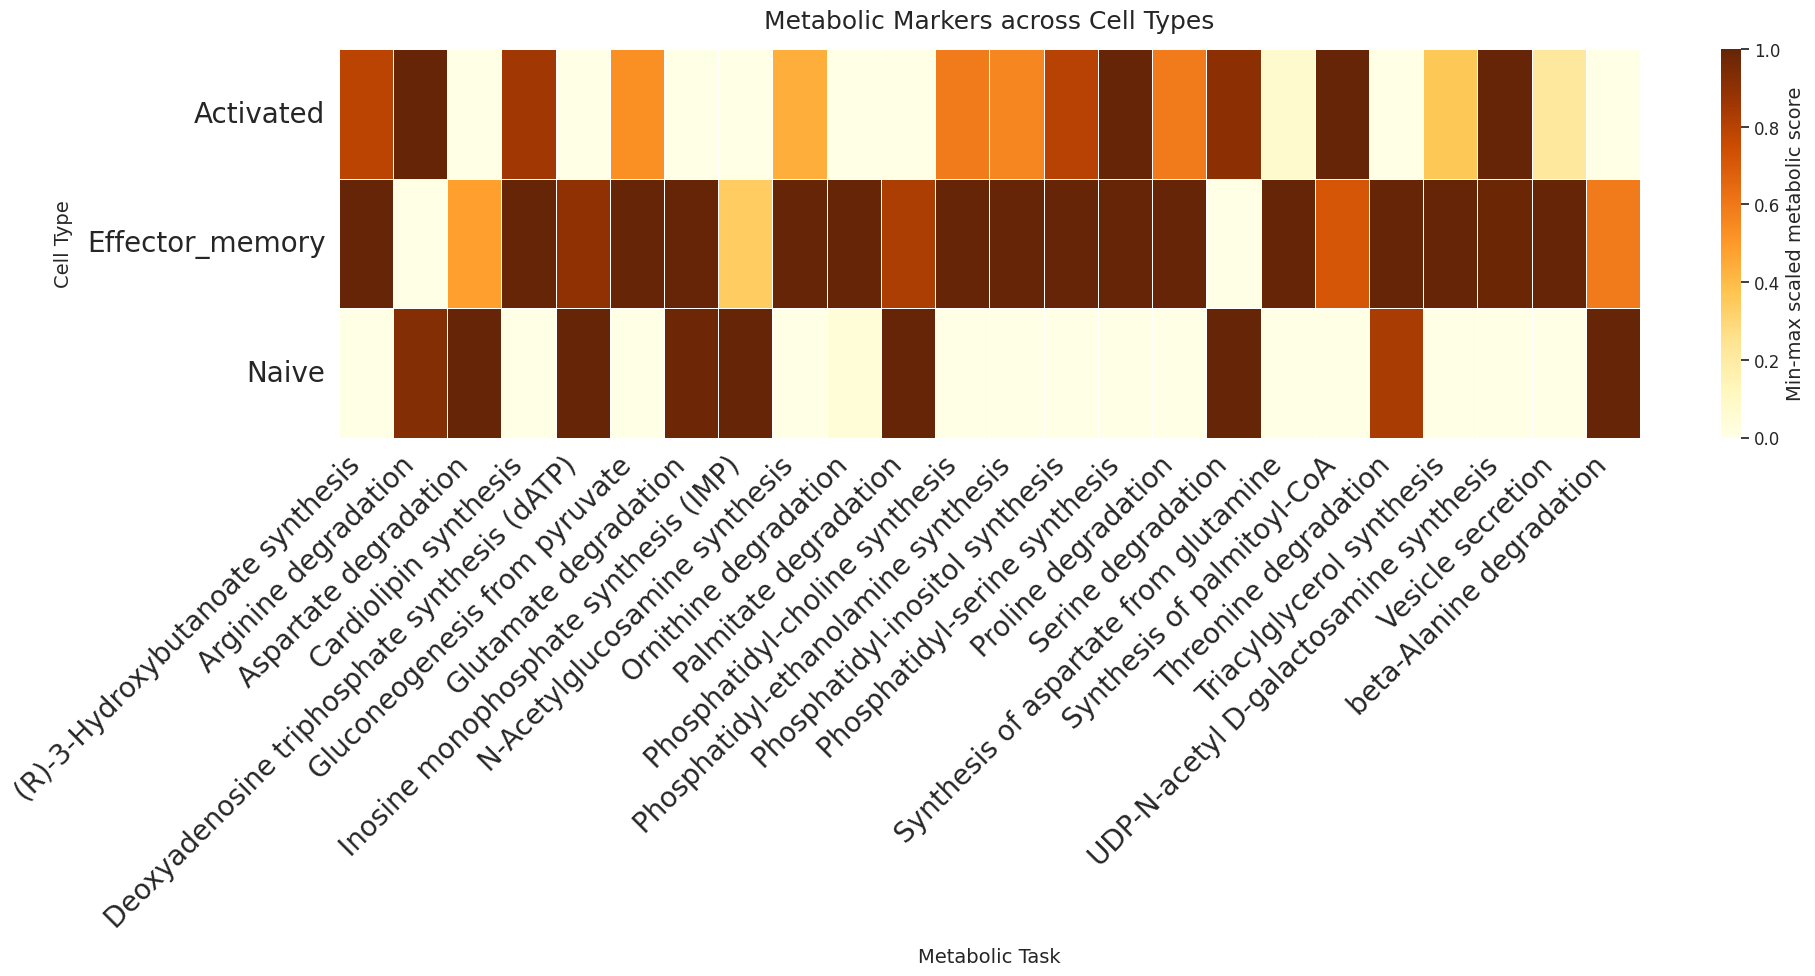

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Option 1: Adjust global font scale for Seaborn (scales everything at once)
sns.set_theme(font_scale=1.2)  # Try 1.2, 1.5, or 2.0 to scale up overall text

# Create figure
plt.figure(figsize=(20, 10))  # Slightly increased figure size for larger labels

# Create heatmap
ax = sns.heatmap(
    normalized_markers,
    cmap="YlOrBr",
    annot=False,
    linewidths=0.5,
    cbar_kws={
        "label": "Min-max scaled metabolic score",
    },
)

# Option 2: Fine-tune individual font sizes
plt.title(
    "Metabolic Markers across Cell Types", fontsize=18, pad=15
)  # Heatmap title
plt.ylabel("Cell Type", fontsize=14, labelpad=10)  # Y-axis label
plt.xlabel("Metabolic Task", fontsize=14, labelpad=10)  # X-axis label

# Increase tick label font sizes (cell type and task names)
plt.xticks(fontsize=20, rotation=45, ha="right")
plt.yticks(fontsize=20, rotation=0)

# Increase colorbar label and tick font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(14)  # Colorbar title/label size
cbar.ax.tick_params(labelsize=12)  # Colorbar numbers size

plt.tight_layout()
#plt.savefig("metabolic_markers_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()